# Lab Report 03 - Running Code

This notebook contains the full runnable practical for `Lab Report 03` with separate Python cells and explanatory comments.

In [1]:
# Import the libraries used in this practical.
# cv2        -> image processing and histogram equalization
# numpy      -> numerical support
# matplotlib -> image display and histogram plotting
# pathlib    -> safe file path handling
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Set a clear default figure size for plots.
plt.rcParams["figure.figsize"] = (10, 6)

In [2]:
# Search for Girl.jpg in likely notebook working locations.
candidate_paths = [
    Path("Girl.jpg"),
    Path("../Girl.jpg"),
    Path(r"C:/Users/kavin/OneDrive/Documents/Projects/Digital Image Processing and Computer Vision/Girl.jpg"),
]

image_path = next((path for path in candidate_paths if path.exists()), None)

if image_path is None:
    raise FileNotFoundError(
        "Could not find 'Girl.jpg'. Keep it in the project root or current working directory."
    )

print(f"Using image: {image_path.resolve()}")

Using image: C:\Users\kavin\OneDrive\Documents\Projects\Digital Image Processing and Computer Vision\Girl.jpg


In [3]:
# Read the image with OpenCV.
# OpenCV loads color images in BGR format by default.
img = cv2.imread(str(image_path))

if img is None:
    raise ValueError(f"OpenCV could not read the image: {image_path}")

print(f"Loaded image shape: {img.shape}")

Loaded image shape: (512, 512, 3)


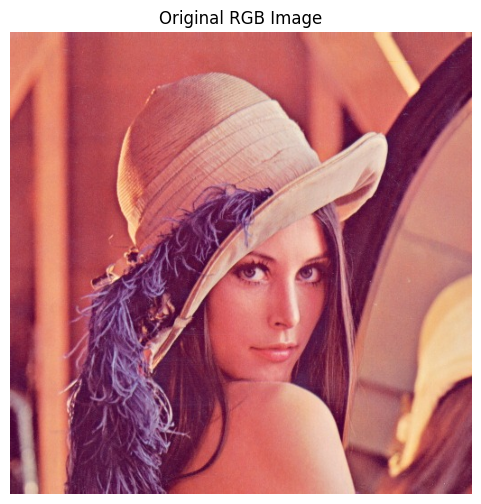

In [4]:
# Convert the original image from BGR to RGB for correct display in matplotlib.
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Display the original RGB image.
plt.figure(figsize=(6, 6))
plt.imshow(img_rgb)
plt.title("Original RGB Image")
plt.axis("off")
plt.show()

In [5]:
# Convert the original BGR image to grayscale.
# Grayscale has only one intensity channel.
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Apply histogram equalization to improve grayscale contrast.
img_gray_eq = cv2.equalizeHist(img_gray)

print(f"Original grayscale intensity range : {img_gray.min()} - {img_gray.max()}")
print(f"Equalized grayscale intensity range: {img_gray_eq.min()} - {img_gray_eq.max()}")

Original grayscale intensity range : 20 - 240
Equalized grayscale intensity range: 0 - 255


In [6]:
# Convert the image to YUV color space.
# Y = luminance, U and V = chrominance components.
img_yuv = cv2.cvtColor(img, cv2.COLOR_BGR2YUV)

# Keep a copy of the original YUV image for before/after histogram comparison.
img_yuv_original = img_yuv.copy()

# Equalize only the Y channel so contrast improves while color is preserved better.
img_yuv[:, :, 0] = cv2.equalizeHist(img_yuv[:, :, 0])

# Convert the equalized YUV image back to RGB for display.
img_color_eq = cv2.cvtColor(img_yuv, cv2.COLOR_YUV2RGB)

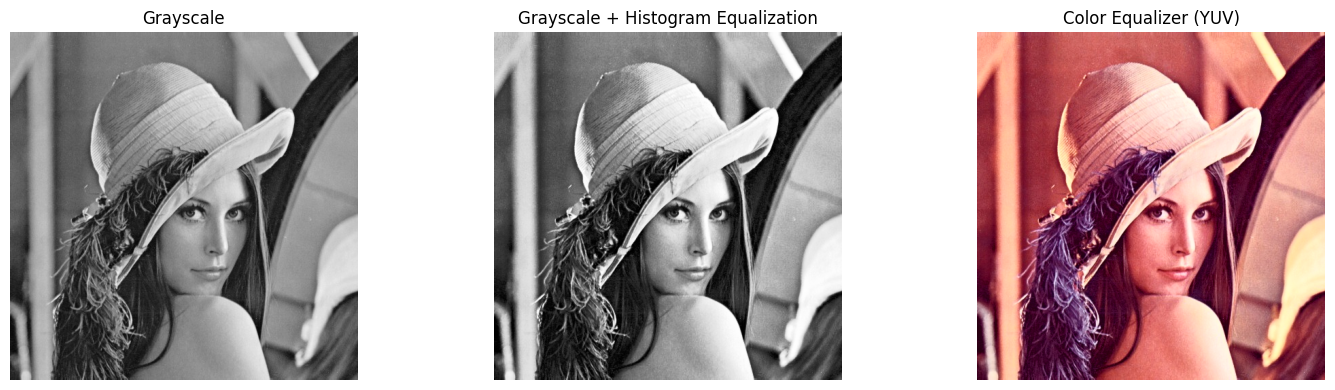

In [7]:
# Display grayscale, equalized grayscale, and color-equalized images.
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.imshow(img_gray, cmap="gray")
plt.title("Grayscale")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(img_gray_eq, cmap="gray")
plt.title("Grayscale + Histogram Equalization")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(img_color_eq)
plt.title("Color Equalizer (YUV)")
plt.axis("off")

plt.tight_layout()
plt.show()

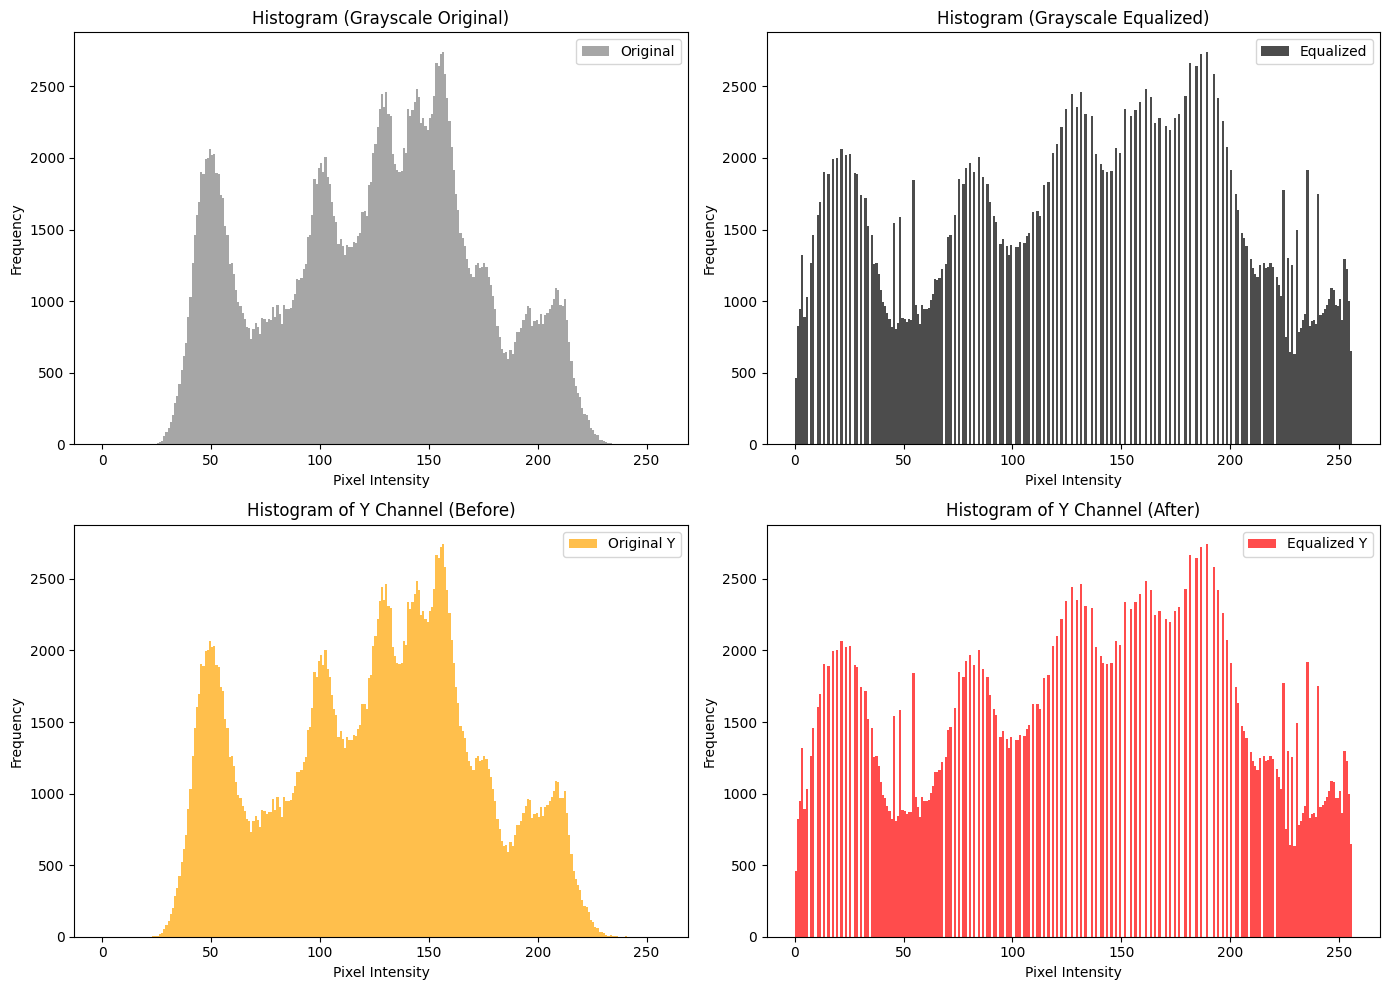

In [8]:
# Plot grayscale and Y-channel histograms in one 2x2 figure.
plt.figure(figsize=(14, 10))

plt.subplot(2, 2, 1)
plt.hist(img_gray.ravel(), bins=256, range=(0, 256), color="gray", alpha=0.7, label="Original")
plt.title("Histogram (Grayscale Original)")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.legend()

plt.subplot(2, 2, 2)
plt.hist(img_gray_eq.ravel(), bins=256, range=(0, 256), color="black", alpha=0.7, label="Equalized")
plt.title("Histogram (Grayscale Equalized)")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.legend()

plt.subplot(2, 2, 3)
plt.hist(img_yuv_original[:, :, 0].ravel(), bins=256, range=(0, 256), color="orange", alpha=0.7, label="Original Y")
plt.title("Histogram of Y Channel (Before)")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.legend()

plt.subplot(2, 2, 4)
plt.hist(img_yuv[:, :, 0].ravel(), bins=256, range=(0, 256), color="red", alpha=0.7, label="Equalized Y")
plt.title("Histogram of Y Channel (After)")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.legend()

plt.tight_layout()
plt.show()

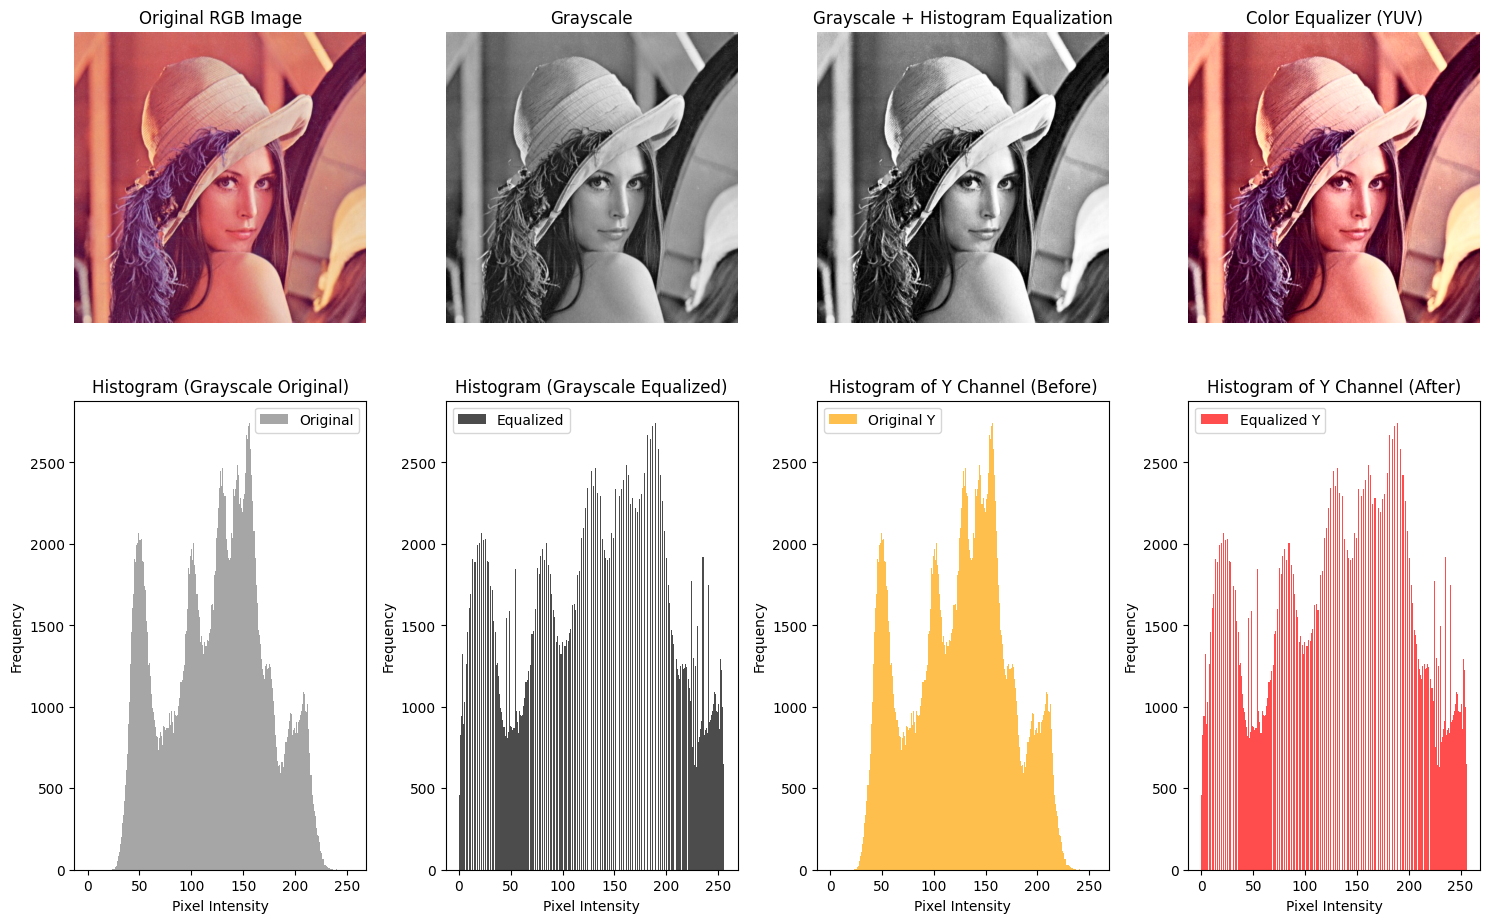

In [9]:
# Display all main results together in a single 2x4 summary layout.
plt.figure(figsize=(15, 10))

plt.subplot(2, 4, 1)
plt.imshow(img_rgb)
plt.title("Original RGB Image")
plt.axis("off")

plt.subplot(2, 4, 2)
plt.imshow(img_gray, cmap="gray")
plt.title("Grayscale")
plt.axis("off")

plt.subplot(2, 4, 3)
plt.imshow(img_gray_eq, cmap="gray")
plt.title("Grayscale + Histogram Equalization")
plt.axis("off")

plt.subplot(2, 4, 4)
plt.imshow(img_color_eq)
plt.title("Color Equalizer (YUV)")
plt.axis("off")

plt.subplot(2, 4, 5)
plt.hist(img_gray.ravel(), bins=256, range=(0, 256), color="gray", alpha=0.7, label="Original")
plt.title("Histogram (Grayscale Original)")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.legend()

plt.subplot(2, 4, 6)
plt.hist(img_gray_eq.ravel(), bins=256, range=(0, 256), color="black", alpha=0.7, label="Equalized")
plt.title("Histogram (Grayscale Equalized)")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.legend()

plt.subplot(2, 4, 7)
plt.hist(img_yuv_original[:, :, 0].ravel(), bins=256, range=(0, 256), color="orange", alpha=0.7, label="Original Y")
plt.title("Histogram of Y Channel (Before)")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.legend()

plt.subplot(2, 4, 8)
plt.hist(img_yuv[:, :, 0].ravel(), bins=256, range=(0, 256), color="red", alpha=0.7, label="Equalized Y")
plt.title("Histogram of Y Channel (After)")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.legend()

plt.tight_layout()
plt.show()

In [10]:
# Final result summary for the practical.
print("Histogram equalization completed successfully!")
print(f"Image shape: {img.shape}")
print(f"Original grayscale intensity range : {img_gray.min()} - {img_gray.max()}")
print(f"Equalized grayscale intensity range: {img_gray_eq.min()} - {img_gray_eq.max()}")
print("Grayscale histogram equalization and Y-channel equalization were both completed.")

Histogram equalization completed successfully!
Image shape: (512, 512, 3)
Original grayscale intensity range : 20 - 240
Equalized grayscale intensity range: 0 - 255
Grayscale histogram equalization and Y-channel equalization were both completed.
